In [2]:
# Import thư viện và đọc dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt phong cách vẽ biểu đồ mặc định cho đẹp mắt
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

# Đọc file dữ liệu từ thư mục raw
# Đảm bảo bạn đã đặt file lung_cancer.csv đúng đường dẫn nhé
df = pd.read_csv('../data/raw/lung_cancer.csv')

# Kiểm tra thông tin các cột, kiểu dữ liệu và giá trị thiếu (missing values)
print("--- THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU ---")
df.info()

# Hiển thị 5 dòng đầu tiên
display(df.head())

--- THÔNG TIN TỔNG QUAN VỀ DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   500

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


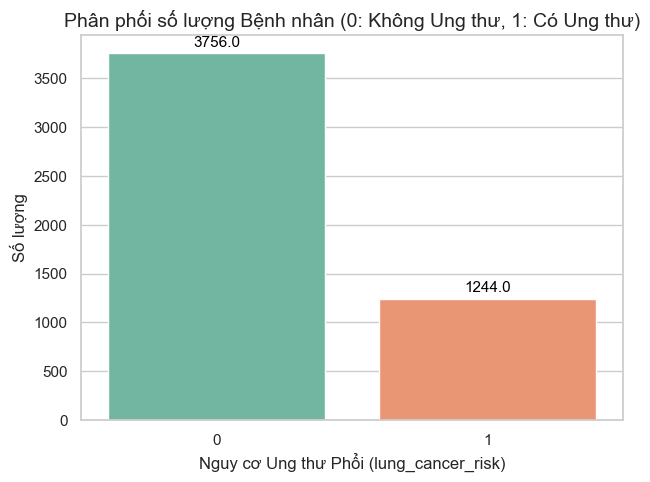

Tỉ lệ phần trăm các lớp:
lung_cancer_risk
0    75.12
1    24.88
Name: proportion, dtype: float64


In [3]:
# Phân phối của biến mục tiêu (Target Variable)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='lung_cancer_risk', palette='Set2')

# Thêm số lượng cụ thể lên trên từng cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Phân phối số lượng Bệnh nhân (0: Không Ung thư, 1: Có Ung thư)', fontsize=14)
plt.xlabel('Nguy cơ Ung thư Phổi (lung_cancer_risk)')
plt.ylabel('Số lượng')
plt.show()

# Tính tỉ lệ phần trăm
print("Tỉ lệ phần trăm các lớp:")
print(df['lung_cancer_risk'].value_counts(normalize=True) * 100)

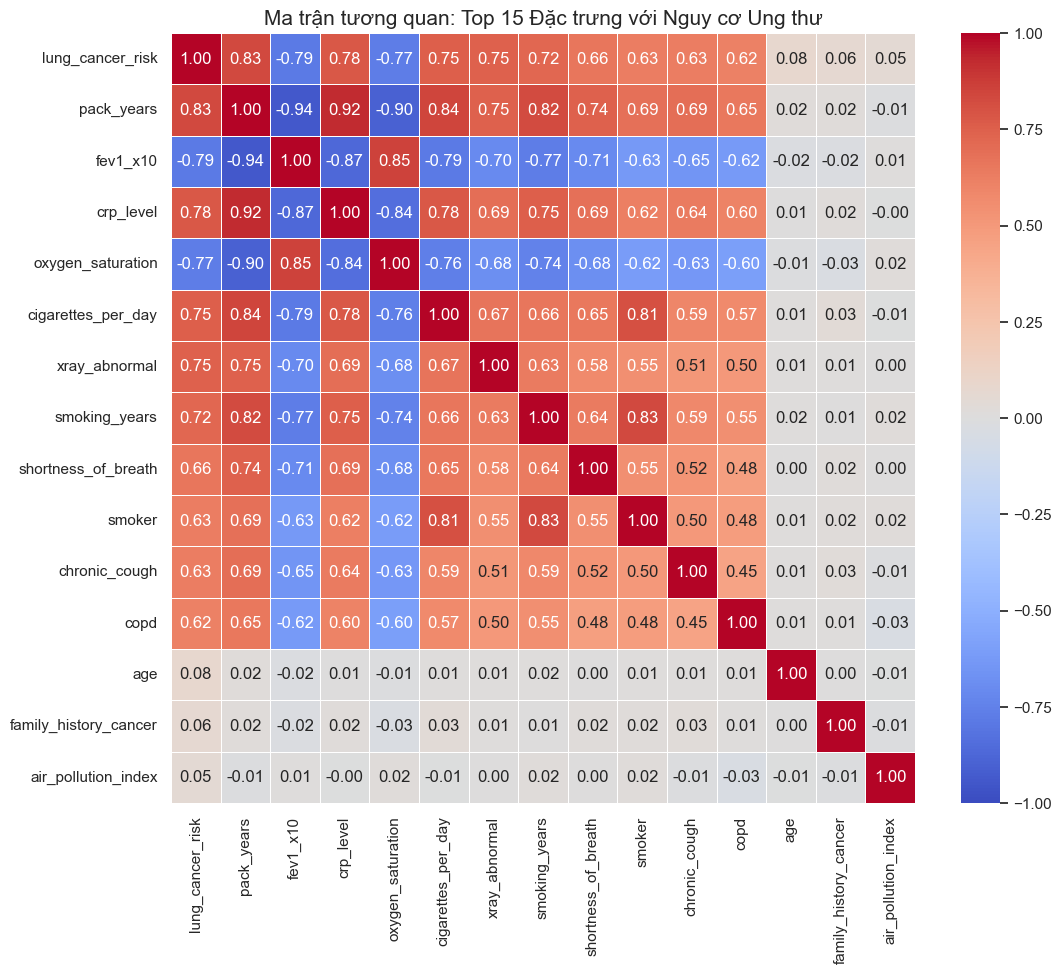

In [4]:
# Ma trận tương quan (Top 15 đặc trưng mạnh nhất)
# Tính hệ số tương quan của tất cả các cột với biến lung_cancer_risk
corr_matrix = df.corr()

# Lấy 15 biến có độ tương quan (trị tuyệt đối) lớn nhất với target
top_features = corr_matrix['lung_cancer_risk'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 10))
# Vẽ Heatmap chỉ cho các biến top này
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan: Top 15 Đặc trưng với Nguy cơ Ung thư', fontsize=15)
plt.show()

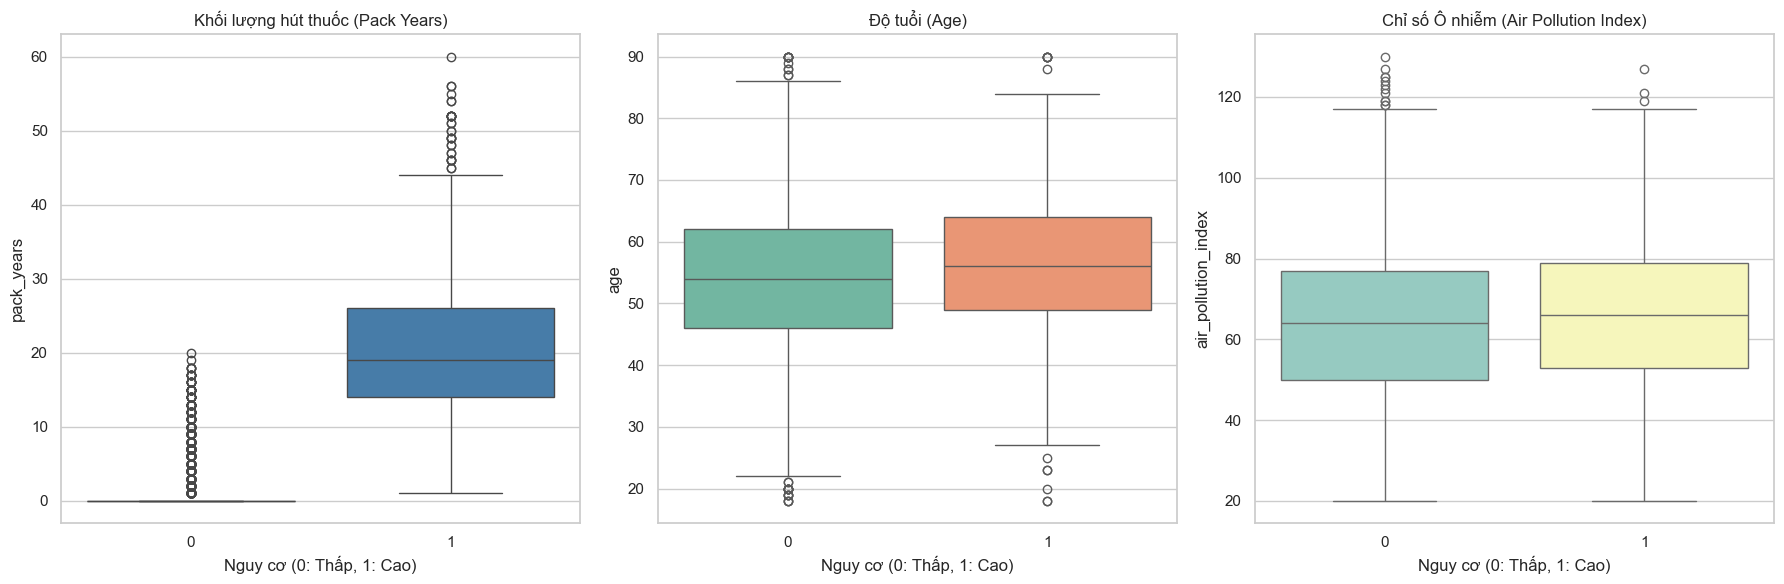

In [5]:
# Trực quan hóa các biến liên tục quan trọng
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Biểu đồ 1: Thâm niên hút thuốc (Pack Years)
sns.boxplot(ax=axes[0], data=df, x='lung_cancer_risk', y='pack_years', palette='Set1')
axes[0].set_title('Khối lượng hút thuốc (Pack Years)')
axes[0].set_xlabel('Nguy cơ (0: Thấp, 1: Cao)')

# Biểu đồ 2: Độ tuổi (Age)
sns.boxplot(ax=axes[1], data=df, x='lung_cancer_risk', y='age', palette='Set2')
axes[1].set_title('Độ tuổi (Age)')
axes[1].set_xlabel('Nguy cơ (0: Thấp, 1: Cao)')

# Biểu đồ 3: Chỉ số ô nhiễm không khí
sns.boxplot(ax=axes[2], data=df, x='lung_cancer_risk', y='air_pollution_index', palette='Set3')
axes[2].set_title('Chỉ số Ô nhiễm (Air Pollution Index)')
axes[2].set_xlabel('Nguy cơ (0: Thấp, 1: Cao)')

plt.tight_layout()
plt.show()

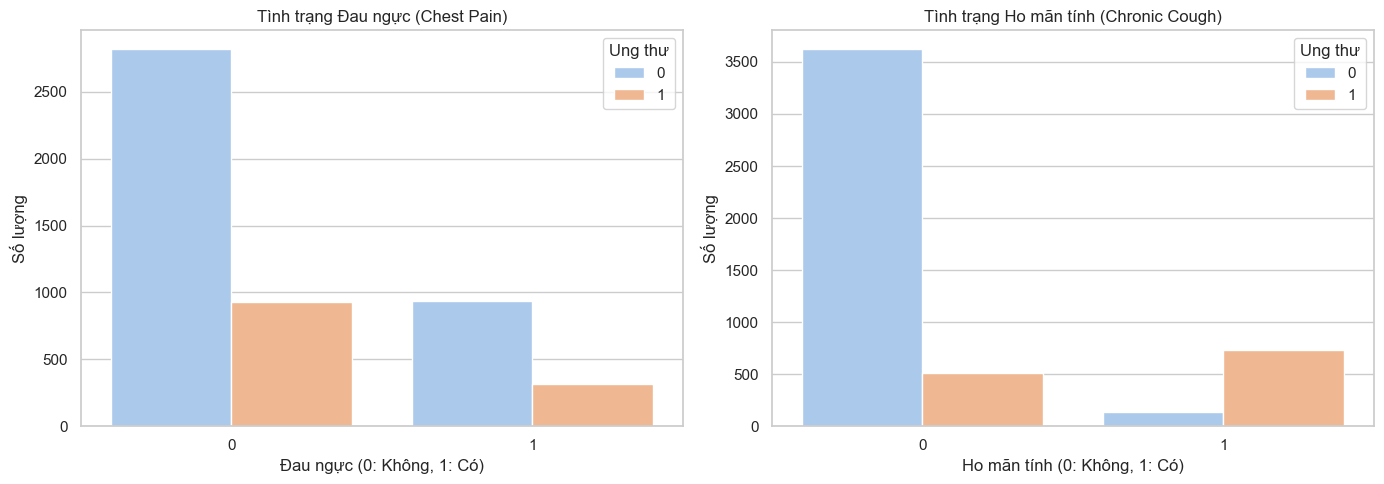

In [6]:
# Trực quan hóa các biến phân loại (Categorical/Binary Features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Đau ngực
sns.countplot(ax=axes[0], data=df, x='chest_pain', hue='lung_cancer_risk', palette='pastel')
axes[0].set_title('Tình trạng Đau ngực (Chest Pain)')
axes[0].set_xlabel('Đau ngực (0: Không, 1: Có)')
axes[0].set_ylabel('Số lượng')
axes[0].legend(title='Ung thư')

# Ho mãn tính
sns.countplot(ax=axes[1], data=df, x='chronic_cough', hue='lung_cancer_risk', palette='pastel')
axes[1].set_title('Tình trạng Ho mãn tính (Chronic Cough)')
axes[1].set_xlabel('Ho mãn tính (0: Không, 1: Có)')
axes[1].set_ylabel('Số lượng')
axes[1].legend(title='Ung thư')

plt.tight_layout()
plt.show()